In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

In [ ]:
df_real = pd.read_csv('https://drive.google.com/uc?export=download&id=16Hwh3nZyQ274UyUSkvex9l9UxCxJHBj3')

In [ ]:
df_syn = pd.read_csv('https://drive.google.com/uc?export=download&id=1KGG_Wzf3MbNlU64uLAZ-GVQ0lI6dTzIt')

Real shape: (891, 9)
Synthetic shape: (219, 9)
Numeric feature summary: Real vs Synthetic


,mean (Real),std (Real),min (Real),50% (Real),max (Real),mean (Synthetic),std (Synthetic),min (Synthetic),50% (Synthetic),max (Synthetic)
Age,29.699118,14.526497,0.42,28.0000,80.0000,29.730594,9.560389,5.90,29.80,52.00
Fare,32.204208,49.693429,0.00,14.4542,512.3292,25.786073,17.857832,7.92,19.72,109.95
SibSp,0.523008,1.102743,0.00,0.0000,8.0000,0.178082,0.479175,0.00,0.00,3.00
Parch,0.381594,0.806057,0.00,0.0000,6.0000,0.082192,0.321411,0.00,0.00,2.00


Numeric feature summary: Real vs Synthetic


,mean (Real),std (Real),min (Real),50% (Real),max (Real),mean (Synthetic),std (Synthetic),min (Synthetic),50% (Synthetic),max (Synthetic)
Age,29.699118,14.526497,0.42,28.0000,80.0000,29.730594,9.560389,5.90,29.80,52.00
Fare,32.204208,49.693429,0.00,14.4542,512.3292,25.786073,17.857832,7.92,19.72,109.95
SibSp,0.523008,1.102743,0.00,0.0000,8.0000,0.178082,0.479175,0.00,0.00,3.00
Parch,0.381594,0.806057,0.00,0.0000,6.0000,0.082192,0.321411,0.00,0.00,2.00


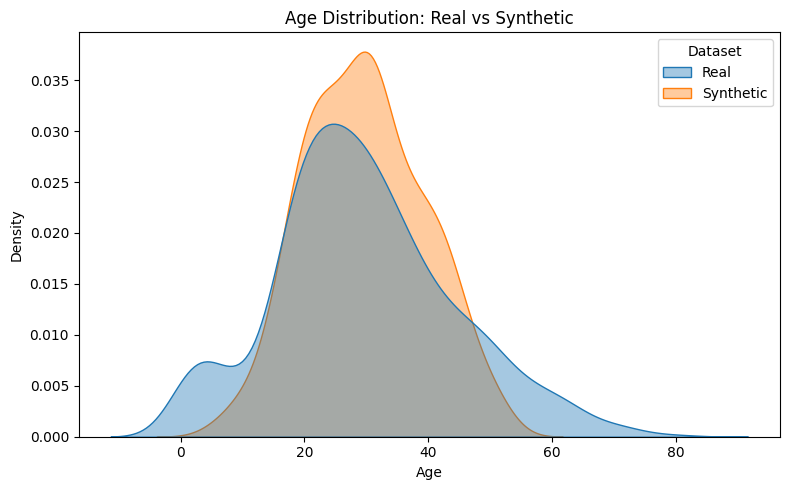

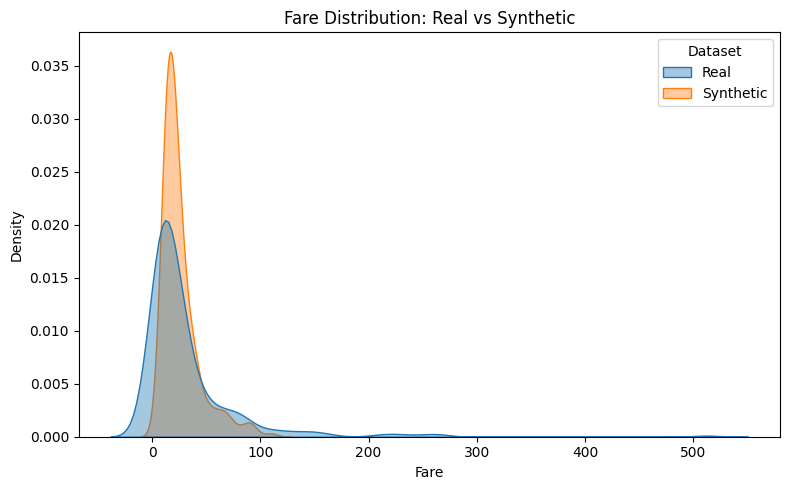

In [ ]:
# ----------------------------------------------------------
# 1. Align schemas: keep common columns
# ----------------------------------------------------------
cols = ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

real = df_real[cols].copy()
syn = df_syn[cols].copy()

real["Dataset"] = "Real"
syn["Dataset"] = "Synthetic"

combined = pd.concat([real, syn], ignore_index=True)

print("Real shape:", real.shape)
print("Synthetic shape:", syn.shape)
num_cols = ["Age", "Fare", "SibSp", "Parch"]

summary_real = real[num_cols].describe().T[["mean", "std", "min", "50%", "max"]]
summary_syn = syn[num_cols].describe().T[["mean", "std", "min", "50%", "max"]]

summary = pd.concat(
    [summary_real.add_suffix(" (Real)"), summary_syn.add_suffix(" (Synthetic)")],
    axis=1
)

print("Numeric feature summary: Real vs Synthetic")
display(summary)
num_cols = ["Age", "Fare", "SibSp", "Parch"]

summary_real = real[num_cols].describe().T[["mean", "std", "min", "50%", "max"]]
summary_syn = syn[num_cols].describe().T[["mean", "std", "min", "50%", "max"]]

summary = pd.concat(
    [summary_real.add_suffix(" (Real)"), summary_syn.add_suffix(" (Synthetic)")],
    axis=1
)

print("Numeric feature summary: Real vs Synthetic")
display(summary)
# KDE / histogram comparison for Age and Fare
for col in ["Age", "Fare"]:
    plt.figure(figsize=(8,5))
    sns.kdeplot(
        data=combined,
        x=col,
        hue="Dataset",
        common_norm=False,
        fill=True,
        alpha=0.4
    )
    plt.title(f"{col} Distribution: Real vs Synthetic")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

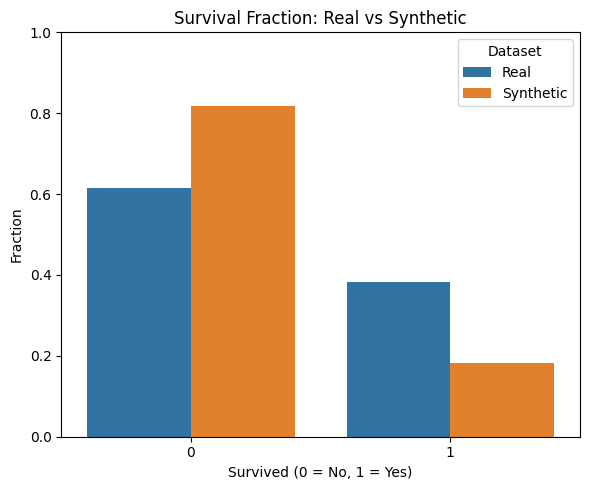

In [ ]:
# Survival fraction within each dataset
surv_counts = combined.groupby(["Dataset", "Survived"]).size().reset_index(name="Count")

# Convert to fractions per dataset
surv_counts["Fraction"] = surv_counts.groupby("Dataset")["Count"].transform(
    lambda s: s / s.sum()
)

plt.figure(figsize=(6,5))
sns.barplot(
    data=surv_counts,
    x="Survived",
    y="Fraction",
    hue="Dataset"
)
plt.title("Survival Fraction: Real vs Synthetic")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fraction")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

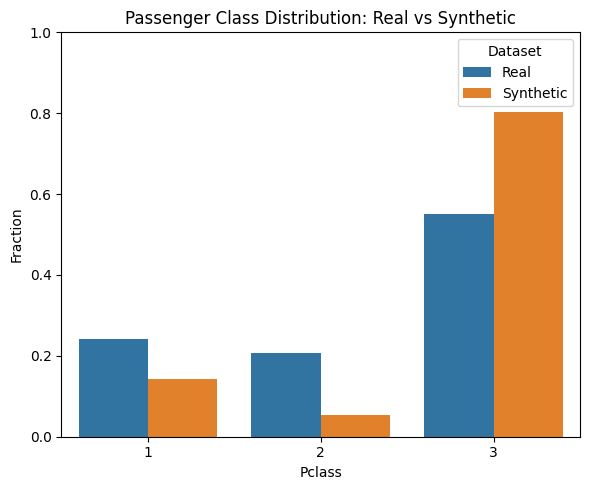

In [ ]:
pclass_counts = combined.groupby(["Dataset", "Pclass"]).size().reset_index(name="Count")
pclass_counts["Fraction"] = pclass_counts.groupby("Dataset")["Count"].transform(
    lambda s: s / s.sum()
)

plt.figure(figsize=(6,5))
sns.barplot(
    data=pclass_counts,
    x="Pclass",
    y="Fraction",
    hue="Dataset"
)
plt.title("Passenger Class Distribution: Real vs Synthetic")
plt.xlabel("Pclass")
plt.ylabel("Fraction")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

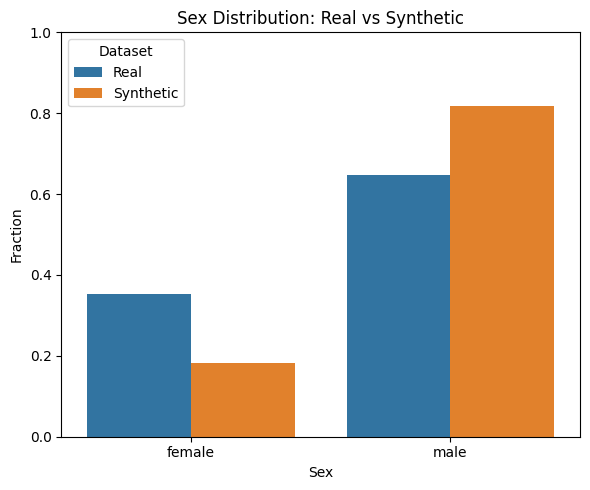

In [ ]:
sex_counts = combined.groupby(["Dataset", "Sex"]).size().reset_index(name="Count")
sex_counts["Fraction"] = sex_counts.groupby("Dataset")["Count"].transform(
    lambda s: s / s.sum()
)

plt.figure(figsize=(6,5))
sns.barplot(
    data=sex_counts,
    x="Sex",
    y="Fraction",
    hue="Dataset"
)
plt.title("Sex Distribution: Real vs Synthetic")
plt.xlabel("Sex")
plt.ylabel("Fraction")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()